In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Data_Wikipedia.csv", on_bad_lines='skip')

print(df.head())

        article   timestamp  views
0  San_Junipero  2016072700      7
1  San_Junipero  2016072800     28
2  San_Junipero  2016072900      7
3  San_Junipero  2016073000     15
4  San_Junipero  2016073100     10


In [3]:
print("\nInfo Data:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82486038 entries, 0 to 82486037
Data columns (total 3 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   article    object
 1   timestamp  int64 
 2   views      int64 
dtypes: int64(2), object(1)
memory usage: 1.8+ GB
None

Missing Values:
article      7674
timestamp       0
views           0
dtype: int64


In [4]:
print("=== RINGKASAN DATA ===")
print(f"Data awal: {len(df)}")
print(f"Duplikat sebelum: {df.duplicated().sum()}")
print(f"Missing sebelum: {df.isnull().sum().sum()}")

=== RINGKASAN DATA ===
Data awal: 82486038
Duplikat sebelum: 16787538
Missing sebelum: 7674


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82486038 entries, 0 to 82486037
Data columns (total 3 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   article    object
 1   timestamp  int64 
 2   views      int64 
dtypes: int64(2), object(1)
memory usage: 1.8+ GB


In [6]:
df.isnull().sum()

article      7674
timestamp       0
views           0
dtype: int64

In [7]:
df = df.dropna()

In [8]:
duplicates = df.duplicated().sum()
print("Jumlah duplikat:", duplicates)

Jumlah duplikat: 16783701


In [9]:
df = df.drop_duplicates()

In [10]:
df.shape

(65694663, 3)

In [11]:
# Convert timestamp ke datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%Y%m%d%H')

In [12]:
df['views'] = pd.to_numeric(df['views'], errors='coerce')
df= df.dropna(subset=['views'])
df= df[df['views'] > 0]

In [13]:
NON_ARTICLE_PREFIXES = [
    'Wikipedia:', 'Help:', 'Portal:', 'Template:', 'File:',
    'Special:', 'Talk:', 'User:', 'Category:', 'Draft:',
    'Book:', 'TimedText:', 'Module:', 'MediaWiki:', 'Main_Page', '404.php'
]

df = df[
    ~df['article'].str.startswith(tuple(NON_ARTICLE_PREFIXES))
]

In [14]:
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day_name()

In [15]:
df = df.sort_values(by='timestamp')

In [16]:
print("=== RINGKASAN DATA ===")
print(f"Data setelah preprocessing: {len(df)}")
print(f"Duplikat sesudah: {df.duplicated().sum()}")
print(f"Missing sesudah: {df.isnull().sum().sum()}")

=== RINGKASAN DATA ===
Data setelah preprocessing: 64940480
Duplikat sesudah: 0
Missing sesudah: 0


In [17]:
print("\nData setelah preprocessing:")
print(df.head())


Data setelah preprocessing:
                                  article  timestamp  views  year  month  \
68299303                     Bobby_Heenan 2015-08-01   6341  2015      8   
29084062                        Green_Day 2015-08-01   4817  2015      8   
73065280  How_to_Train_Your_Dragon_(film) 2015-08-01   2605  2015      8   
70884266                   Mariana_Trench 2015-08-01   5279  2015      8   
55635536                     Steve_Albini 2015-08-01    506  2015      8   

               day  
68299303  Saturday  
29084062  Saturday  
73065280  Saturday  
70884266  Saturday  
55635536  Saturday  


In [18]:
df.describe()

,timestamp,views,year,month
count,64940480,6.494048e+07,6.494048e+07,6.494048e+07
mean,2021-03-28 05:57:31.351589632,2.472883e+03,2.020731e+03,6.614584e+00
min,2015-08-01 00:00:00,1.000000e+00,2.015000e+03,1.000000e+00
25%,2018-09-29 00:00:00,3.000000e+02,2.018000e+03,4.000000e+00
50%,2021-06-04 00:00:00,9.480000e+02,2.021000e+03,7.000000e+00
75%,2023-11-04 00:00:00,2.512000e+03,2.023000e+03,1.000000e+01
max,2026-01-31 00:00:00,1.495413e+07,2.026000e+03,1.200000e+01
std,NaN,1.117551e+04,3.001129e+00,3.482916e+00


# 5V

## Volume

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64940480 entries, 68299303 to 82486037
Data columns (total 6 columns):
 #   Column     Dtype         
---  ------     -----         
 0   article    object        
 1   timestamp  datetime64[ns]
 2   views      int64         
 3   year       int32         
 4   month      int32         
 5   day        object        
dtypes: datetime64[ns](1), int32(2), int64(1), object(2)
memory usage: 2.9+ GB


<Axes: xlabel='article'>

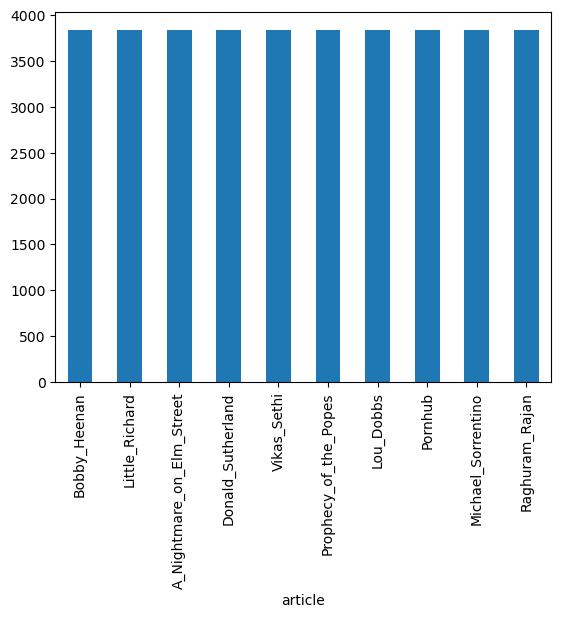

In [20]:
df['article'].value_counts().head(10).plot(kind='bar')

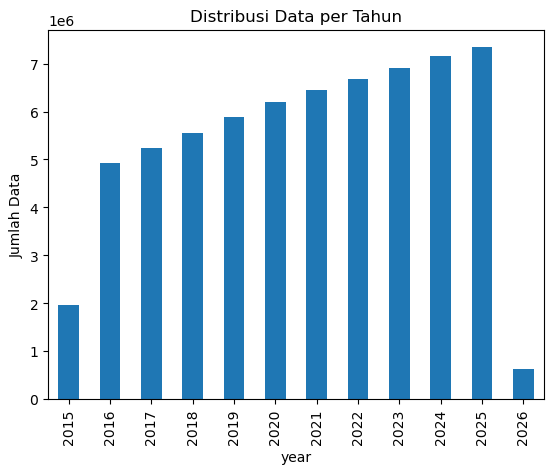

In [21]:
df['year'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribusi Data per Tahun")
plt.ylabel("Jumlah Data")
plt.show()

## Velocity 

<Axes: xlabel='timestamp'>

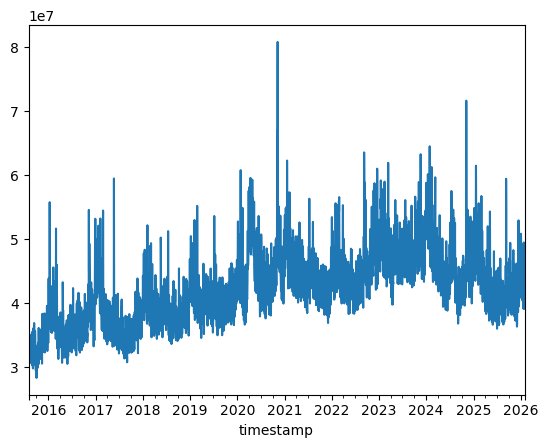

In [22]:
df_harian = df.groupby('timestamp')['views'].sum()

df_harian.plot()

<Axes: xlabel='timestamp'>

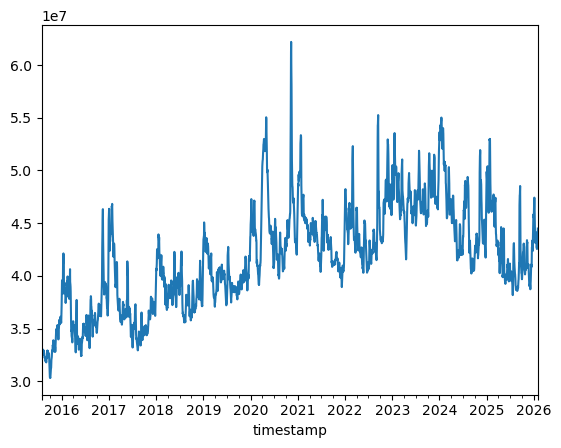

In [23]:
df_harian = df.groupby('timestamp')['views'].sum()

df_harian.rolling(7).mean().plot()

## Variety

In [24]:
print("Tipe data tiap kolom:\n")
print(df.dtypes)
print("\nJumlah kolom:", df.shape[1])

Tipe data tiap kolom:

article              object
timestamp    datetime64[ns]
views                 int64
year                  int32
month                 int32
day                  object
dtype: object

Jumlah kolom: 6


#  VISUALISASI

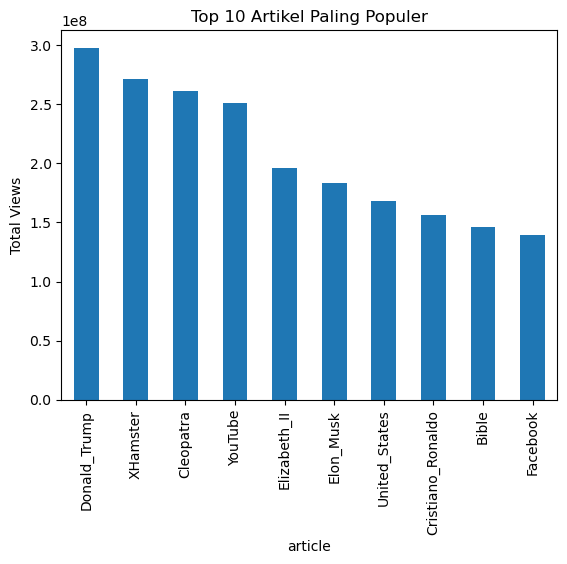

In [25]:
# Artikel Populer 
top_articles = df.groupby('article')['views'].sum().sort_values(ascending=False).head(10)

top_articles.plot(kind='bar')
plt.title("Top 10 Artikel Paling Populer")
plt.ylabel("Total Views")
plt.show()

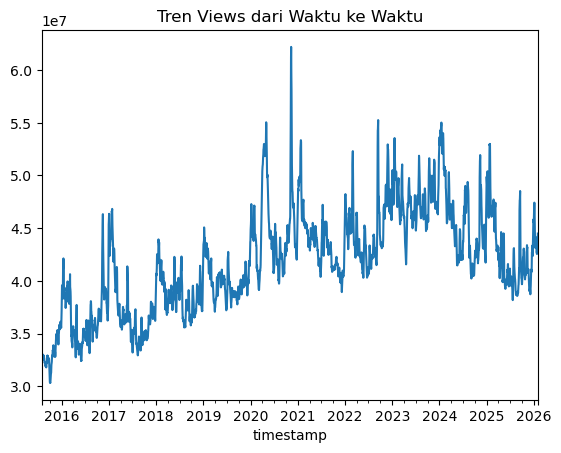

In [26]:
# Tren waktu

df_trend = df.groupby('timestamp')['views'].sum()

df_trend.rolling(7).mean().plot()
plt.title("Tren Views dari Waktu ke Waktu")
plt.show()

In [27]:
# Lonjakan (spike)
df_daily = df.groupby('timestamp')['views'].sum()

spike = df_daily[df_daily > df_daily.mean() + 2*df_daily.std()]
print(spike.head())

timestamp
2016-01-11    55790942
2016-11-09    54587379
2016-12-29    53207996
2017-02-06    53249820
2017-02-27    54484391
Name: views, dtype: int64


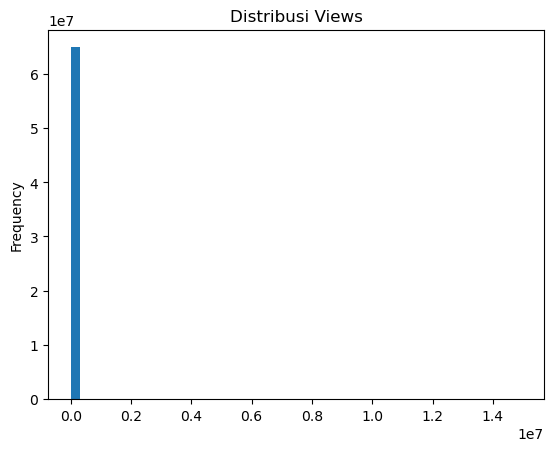

In [28]:
# Perilaku pengguna
df['views'].plot(kind='hist', bins=50)
plt.title("Distribusi Views")
plt.show()

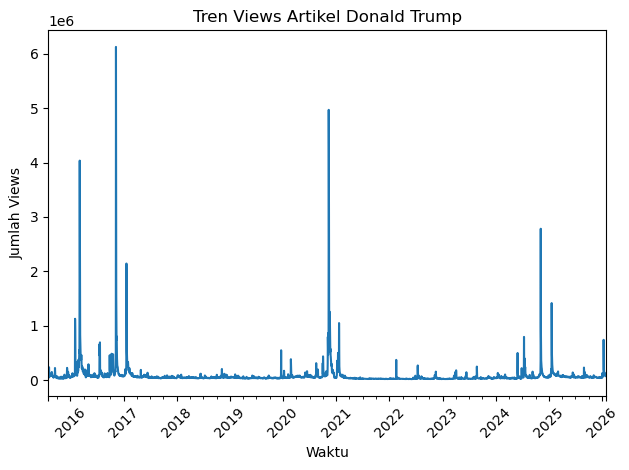

In [35]:
import matplotlib.pyplot as plt

# Filter data untuk artikel Donald Trump
df_trump = df[df['article'] == 'Donald_Trump']

# Kelompokkan berdasarkan waktu (timestamp)
trend_trump = df_trump.groupby('timestamp')['views'].sum()

# Plot grafik
trend_trump.plot()

plt.title("Tren Views Artikel Donald Trump")
plt.xlabel("Waktu")
plt.ylabel("Jumlah Views")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [29]:
# Menghitung total views per artikel
top_articles = (
    df
    .groupby('article')['views']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Ambil 3 artikel teratas
top_3 = top_articles.head(3)

# Tampilkan hasil
print(top_3)

        article      views
0  Donald_Trump  297839586
1      XHamster  271518905
2     Cleopatra  261053158


=== PERIODE LONJAKAN ARTIKEL DONALD TRUMP ===
start_date   end_date  peak_views  duration_days
2016-02-02 2016-02-03     1126257              2
2016-03-02 2016-03-02      549599              1
2016-03-04 2016-03-10     4034771              7
2016-07-19 2016-07-20      656938              2
2016-07-22 2016-07-22      692081              1
2016-11-08 2016-11-15     6125896              8
2017-01-20 2017-01-23     2142054              4
2019-12-19 2019-12-19      547001              1
2020-11-04 2020-11-05      793477              2
2020-11-07 2020-11-22     4968836             16
2021-01-20 2021-01-21     1047386              2
2024-07-14 2024-07-14      792587              1
2024-11-06 2024-11-08     2782082              3
2025-01-20 2025-01-21     1415168              2
2026-01-12 2026-01-12      739258              1

Rata-rata durasi lonjakan : 3.5 hari
Lonjakan terpanjang       : 16 hari
Threshold views           : 504,629


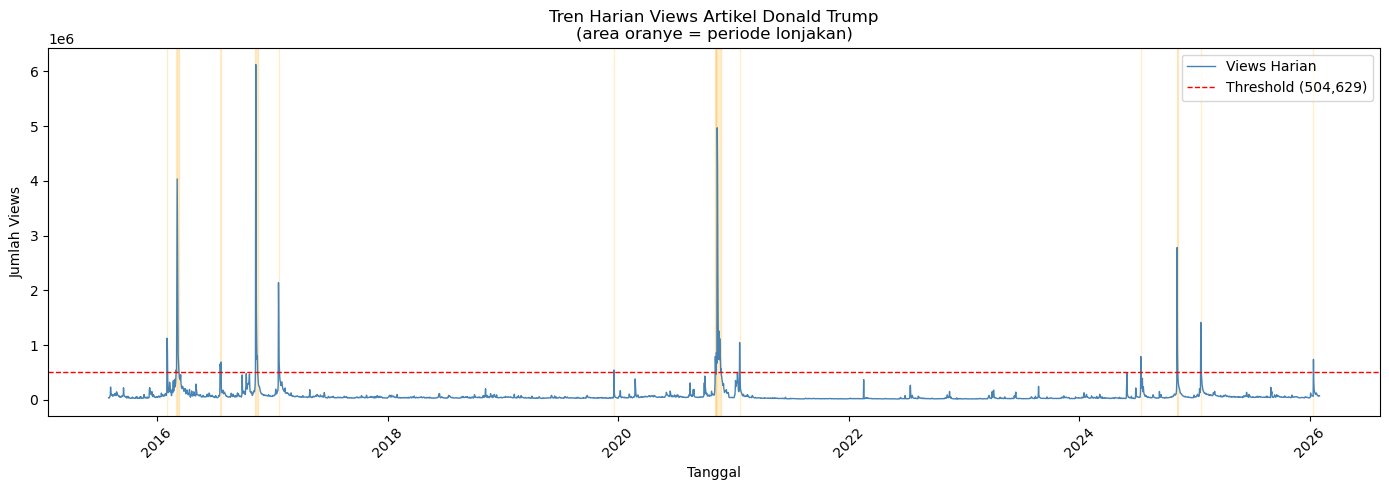

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Persiapan data Trump ---
df_trump = df[df['article'] == 'Donald_Trump'].copy()

# Konversi timestamp ke datetime (handle format campuran)
df_trump['date'] = pd.to_datetime(
    df_trump['timestamp'].astype(str).str[:10],
    format='mixed',
    dayfirst=False
).dt.normalize()

# Agregasi per hari
daily_trump = df_trump.groupby('date')['views'].sum().reset_index()
daily_trump.columns = ['date', 'views']
daily_trump = daily_trump.sort_values('date')

# --- Deteksi lonjakan (spike): views > rata-rata + 2x std ---
mean_views = daily_trump['views'].mean()
std_views  = daily_trump['views'].std()
threshold  = mean_views + 2 * std_views

daily_trump['is_spike'] = daily_trump['views'] > threshold

# --- Hitung durasi setiap periode lonjakan ---
daily_trump['spike_group'] = (daily_trump['is_spike'] != daily_trump['is_spike'].shift()).cumsum()

spike_durations = (
    daily_trump[daily_trump['is_spike']]
    .groupby('spike_group')
    .agg(
        start_date=('date', 'min'),
        end_date=('date', 'max'),
        peak_views=('views', 'max'),
        duration_days=('date', lambda x: (x.max() - x.min()).days + 1)
    )
    .reset_index(drop=True)
)

print("=== PERIODE LONJAKAN ARTIKEL DONALD TRUMP ===")
print(spike_durations.to_string(index=False))
print(f"\nRata-rata durasi lonjakan : {spike_durations['duration_days'].mean():.1f} hari")
print(f"Lonjakan terpanjang       : {spike_durations['duration_days'].max()} hari")
print(f"Threshold views           : {threshold:,.0f}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(daily_trump['date'], daily_trump['views'], color='steelblue', linewidth=1, label='Views Harian')
ax.axhline(threshold, color='red', linestyle='--', linewidth=1, label=f'Threshold ({threshold:,.0f})')

for _, row in spike_durations.iterrows():
    ax.axvspan(row['start_date'], row['end_date'], alpha=0.2, color='orange', label='_nolegend_')

ax.set_title('Tren Harian Views Artikel Donald Trump\n(area oranye = periode lonjakan)')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Jumlah Views')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

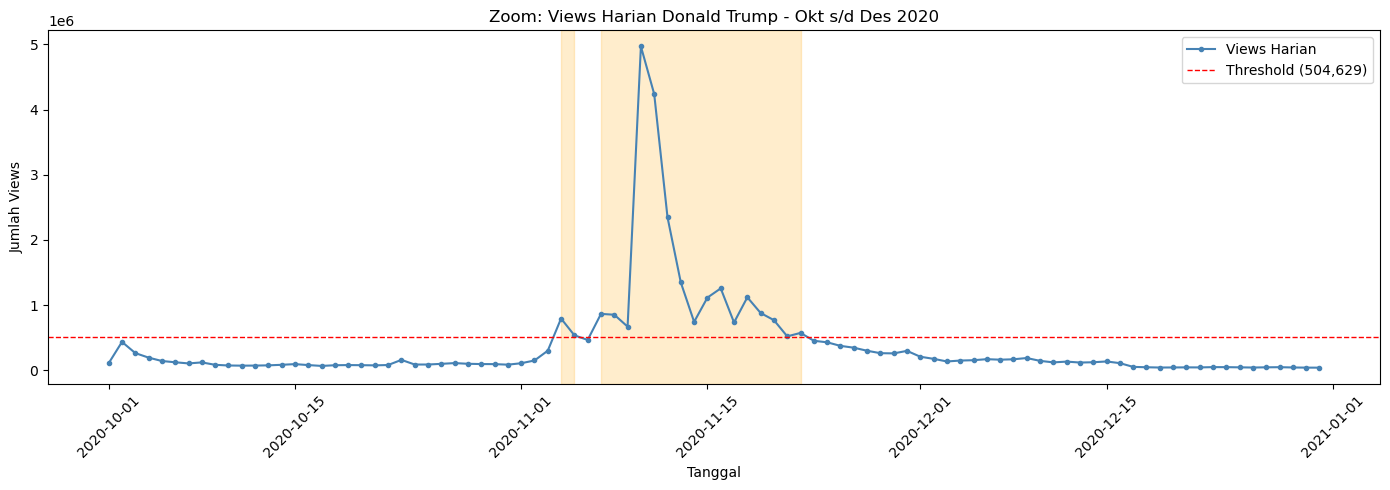

In [34]:
# Zoom in ke periode tertentu, misal sekitar Pemilu 2020
fig, ax = plt.subplots(figsize=(14, 5))

# Filter tanggal yang mau di-zoom
mask = (daily_trump['date'] >= '2020-10-01') & (daily_trump['date'] <= '2020-12-31')
zoom = daily_trump[mask]

ax.plot(zoom['date'], zoom['views'], color='steelblue', linewidth=1.5, marker='o', markersize=3, label='Views Harian')
ax.axhline(threshold, color='red', linestyle='--', linewidth=1, label=f'Threshold ({threshold:,.0f})')

# Arsir area spike
for _, row in spike_durations.iterrows():
    if row['start_date'] >= pd.Timestamp('2020-10-01') and row['end_date'] <= pd.Timestamp('2020-12-31'):
        ax.axvspan(row['start_date'], row['end_date'], alpha=0.2, color='orange')

ax.set_title('Zoom: Views Harian Donald Trump - Okt s/d Des 2020')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Jumlah Views')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
# Filter artikel yang tidak diinginkan
blacklist = ['XHamster', 'Pornhub', 'pornography']  # tambahkan yang mau dihapus

df_clean = df[~df['article'].str.contains('|'.join(blacklist), case=False, na=False)]

In [37]:
# Menghitung total views per artikel
top_articles = (
    df_clean
    .groupby('article')['views']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Ambil 3 artikel teratas
top_3 = top_articles.head(3)

# Tampilkan hasil
print(top_3)

        article      views
0  Donald_Trump  297839586
1     Cleopatra  261053158
2       YouTube  251416404


# Insight Selanjutnya

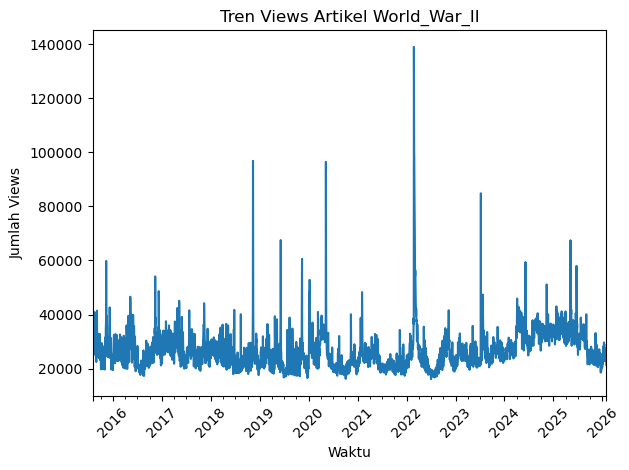

In [38]:
import matplotlib.pyplot as plt

df_trump = df[df['article'] == 'World_War_II']

# Kelompokkan berdasarkan waktu (timestamp)
trend_trump = df_trump.groupby('timestamp')['views'].sum()

# Plot grafik
trend_trump.plot()

plt.title("Tren Views Artikel World_War_II")
plt.xlabel("Waktu")
plt.ylabel("Jumlah Views")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [39]:
# Cari artikel yang mengandung kata tertentu
war_articles = df[df['article'].str.contains('War|war|Hitler|Ukraine|Hamas|Israel', na=False)]

# Lihat top viewsnya
top_war = war_articles.groupby('article')['views'].sum().sort_values(ascending=False).head(10)
print(top_war)

article
World_War_II                        103212107
Adolf_Hitler                         93798344
World_War_I                          83428844
Arnold_Schwarzenegger                72011135
Star_Wars                            69512798
Israel                               68823343
Edward_VIII                          64598238
Vietnam_War                          57978762
2022_Russian_invasion_of_Ukraine     57325645
Avengers:_Infinity_War               57279695
Name: views, dtype: int64


In [40]:
# Filter artikel yang tidak diinginkan
blacklist = ['XHamster', 'Pornhub', 'pornography' 'XXX', 'XXXX']  # tambahkan yang mau dihapus

df_clean = df[~df['article'].str.contains('|'.join(blacklist), case=False, na=False)]

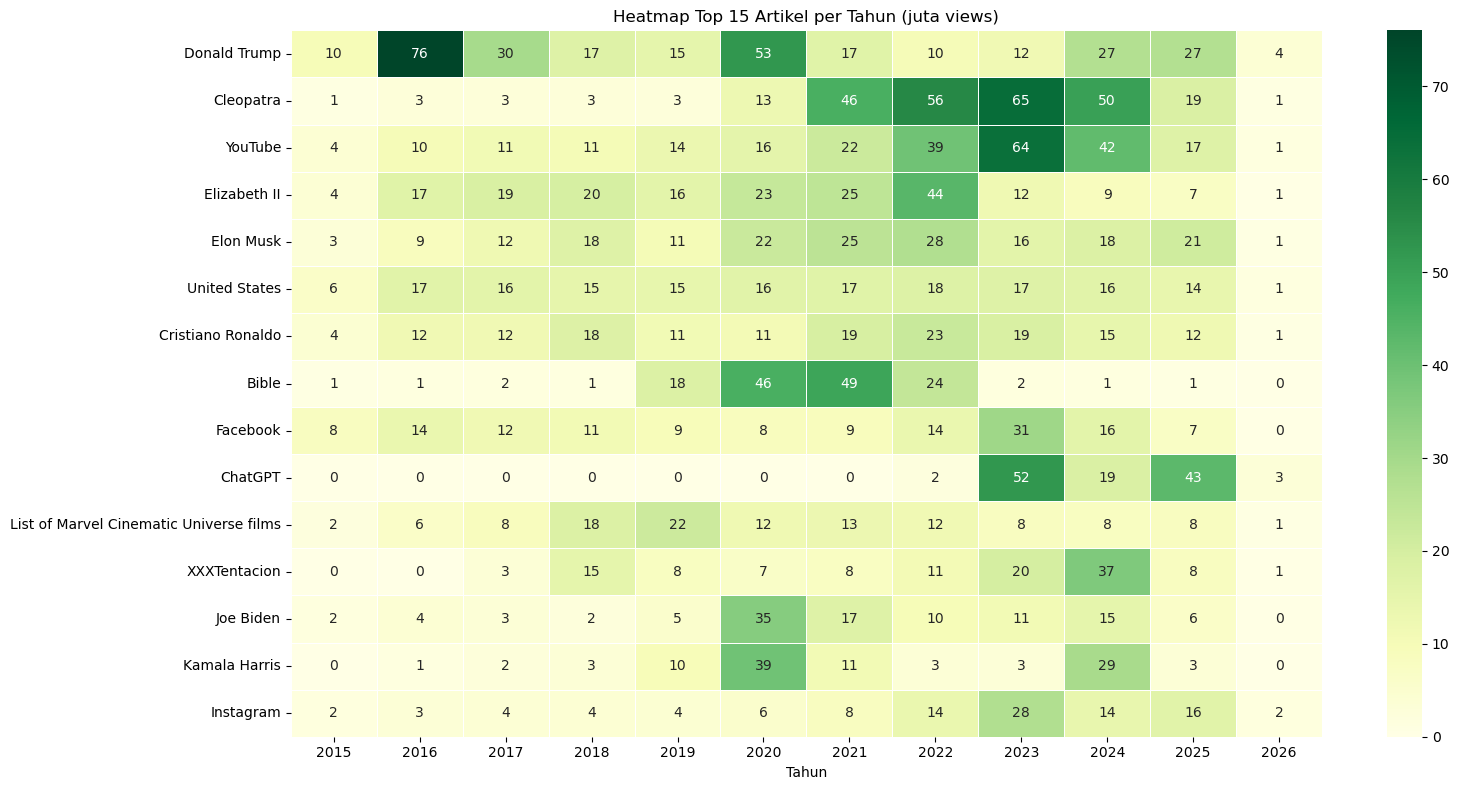

In [41]:
# ===== HEATMAP TOP ARTIKEL PER TAHUN (PANDAS) =====

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Agregasi: total views per artikel per tahun ---
yearly_views = (
    df_clean
    .groupby(['year', 'article'])['views']
    .sum()
    .reset_index(name='total_views')
)

# --- Ambil top N artikel ---
TOP_N = 15

top_articles = (
    df_clean
    .groupby('article')['views']
    .sum()
    .sort_values(ascending=False)
    .head(TOP_N)
    .index
)

# --- Filter hanya top artikel ---
heat_pd = yearly_views[yearly_views['article'].isin(top_articles)]

# --- Pivot ---
pivot = heat_pd.pivot(
    index='article',
    columns='year',
    values='total_views'
).fillna(0)

# --- Urutkan ---
pivot['total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('total', ascending=False).drop(columns='total')

# --- Rapihin nama artikel ---
pivot.index = pivot.index.str.replace('_', ' ', regex=False)

# --- Plot ---
plt.figure(figsize=(16, 8))

sns.heatmap(
    pivot / 1e6,
    cmap='YlGn',
    linewidths=0.4,
    linecolor='white',
    annot=True,
    fmt='.0f'
)

plt.title(f'Heatmap Top {TOP_N} Artikel per Tahun (juta views)')
plt.xlabel('Tahun')
plt.ylabel('')

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()